In [1]:
import numpy as np
import xtrack as xt
import xobjects as xo
import xpart as xp
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import constants 
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Generalized variables
textwidth_cm = 16.50764  # Text width in cm
aspect_ratio = 0.618     # Aspect ratio (height/width) using the golden ratio

# Font sizes
label_fontsize = 10
legend_fontsize = 10
tick_fontsize = 8
colorbar_label_fontsize = 10
colorbar_tick_fontsize = 8
offset_text_fontsize = 10
tick_fontsize = 8
errorbar_capsize = 5

# Convert text width from cm to inches
textwidth_in = textwidth_cm / 2.54

# Calculate figure size based on text width and aspect ratio
fig_width = textwidth_in
fig_height = textwidth_in * aspect_ratio

In [2]:
from ion_properties import lead,calcium,xenon,xenon2nd

ions=lead,calcium,xenon

In [ ]:
ion_loop=xenon

loaded_data = np.load(f'results/cooling_rates/longitudinal/{ion_loop.name}.npz')

delta = loaded_data['delta']
zeta = loaded_data['zeta']
state = loaded_data['state']
x = loaded_data['x']
time = loaded_data['time']
s_per_turn = loaded_data['s_per_turn']
px = loaded_data['px']
action_x = loaded_data['action_x']
action_y = loaded_data['action_y']
emittance_x = loaded_data['emittance_x']

excited0 = state[1, :] == 2
fraction_excitation = sum(excited0) / len(excited0)
rms_dp_p = np.std(delta, axis=1)

/home/pkruyt/miniforge3/envs/xsuite_coolers/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


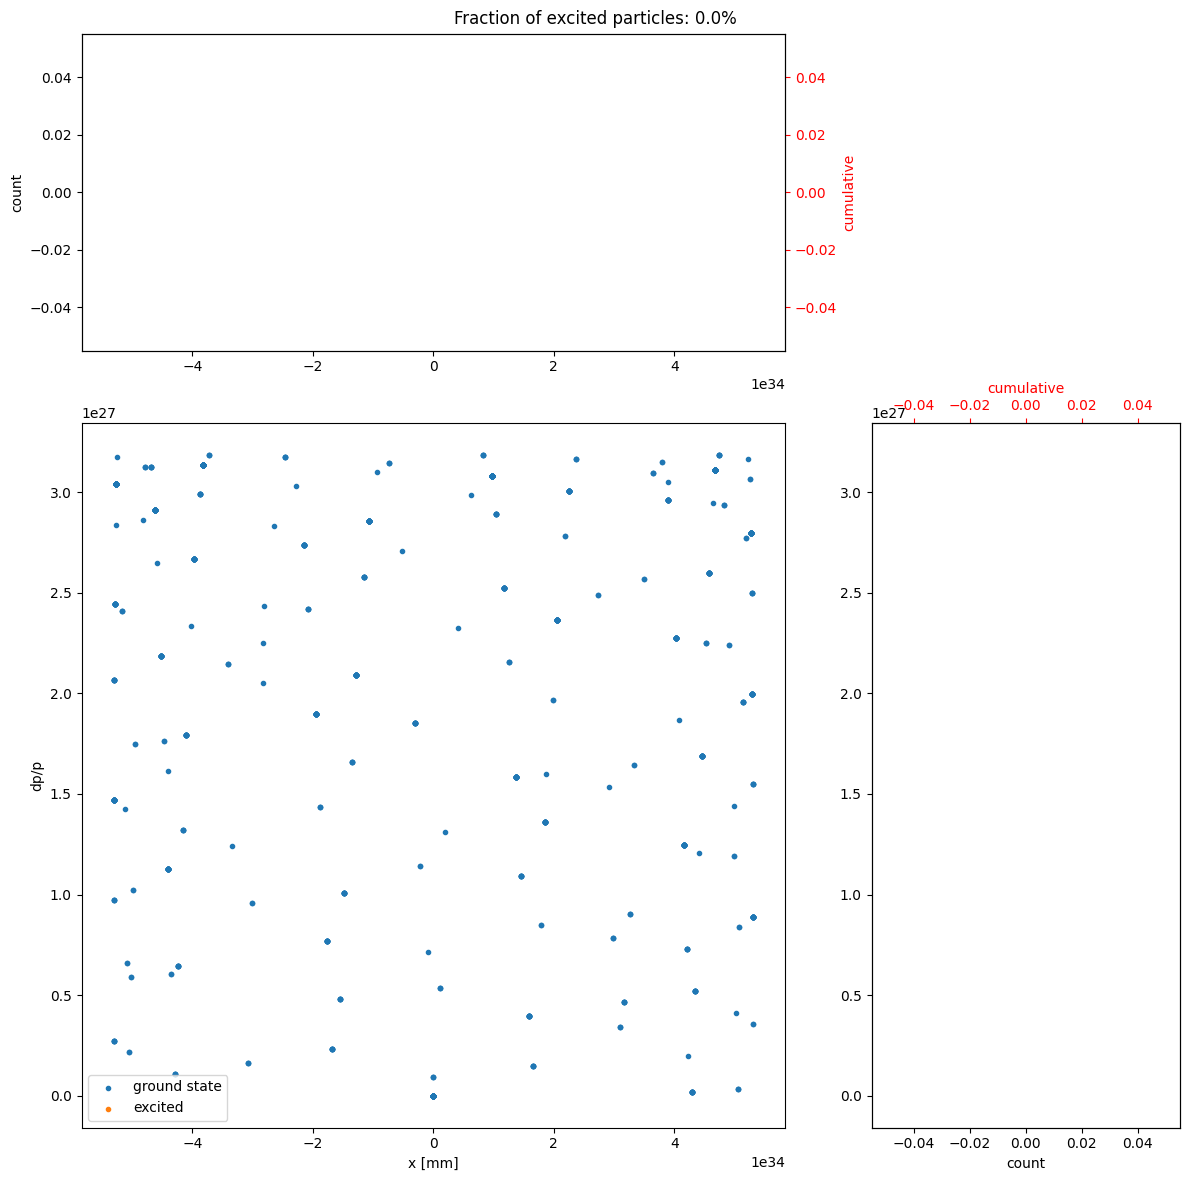

In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np


fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(3, 3)
ax_main = plt.subplot(gs[1:3, :2])
ax_xDist = plt.subplot(gs[0, :2], sharex=ax_main)
ax_yDist = plt.subplot(gs[1:3, 2], sharey=ax_main)

ax_main.scatter(x[1,:]*1e3, delta[1,:], marker='.',label='ground state')
ax_main.scatter(x[1,:][excited0]*1e3, delta[1,:][excited0], marker='.',label='excited')
ax_main.set(xlabel="x [mm]", ylabel="dp/p")

ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

ax_xDist.hist(x[1,:][excited0]*1e3, bins=100, align='mid')
ax_xDist.set(ylabel='count')
ax_xCumDist = ax_xDist.twinx()
ax_xCumDist.hist(x[1,:][excited0]*1e3, bins=100, cumulative=True, histtype='step', density=True, color='r', align='mid')
ax_xCumDist.tick_params('y', colors='r')
ax_xCumDist.set_ylabel('cumulative', color='r')


ax_yDist.hist(delta[1,:][excited0], bins=100, orientation='horizontal', align='mid')
ax_yDist.set(xlabel='count')
ax_yCumDist = ax_yDist.twiny()
ax_yCumDist.hist(delta[1,:][excited0], bins=100, cumulative=True, histtype='step', density=True, color='r', align='mid', orientation='horizontal')
ax_yCumDist.tick_params('x', colors='r')
ax_yCumDist.set_xlabel('cumulative', color='r')

# Setting tick label format for y-axis
ax_xDist.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
ax_xCumDist.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
ax_main.legend()

plt.suptitle(f'Fraction of excited particles: {fraction_excitation*100:.3}%')

plt.tight_layout()
plt.show()
